# IY021 – SimCLR Embeddings + SVM on ALL Experimental Data

**Goal:** Same analysis as `IY021_test_simclr_exp_data.ipynb` but including all experiments
with clear carbon-source labels from `EXP-25-IY008/4_transformed_exp_time_series/`.

**Environments (labels) — verified via `get_exp_summary`:**
- `0` — 2% glucose (experiments 19316, 18589, 19330)
- `1` — 0.1% glucose (experiments 19566, 18446, 19394)
- `2` — 0.01% glucose (experiments 19554, 20213)
- `3` — 2% galactose (experiment 19391 — pump: 2% raffinose → 2% galactose)
- `4` — 0.01% galactose (experiment 19392 — pump: 2% glucose → 0.01% galactose)

**Excluded experiments:**
- `18360` — no explicit carbon source concentration in filename ("2min" refers to interval)
- `18464` — mock condition (not a carbon source concentration)

**Length handling:** All series truncated to the global minimum timepoint count across
all loaded files. SimCLR models were trained on longer sequences so performance may differ
from the original notebook.

**Models evaluated (28 checkpoints):**
- IY017: instance-norm models, various batch sizes and d_model (D8, D16, D128)
- IY022: single-dataset models with global / joint / batch-wise normalisation
- IY023: mixed-dataset (all 4 sources) models with batch-wise normalisation

In [1]:
import re
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR  = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
EXP_DIR   = Path("/home/ianyang/stochastic_simulations/experiments")
META_COLS = ["id", "group", "experiment"]

RANDOM_STATE = 42
IY021_DIR = EXP_DIR / "EXP-26-IY021"
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Experimental Data & Assign Labels

In [2]:
# Verify experimental conditions using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_EXPERIMENT_OMIDS = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "18589": "18589_2020_02_10_steadystate_glucose_898S_2w2_01",
    "19330": "19330_2020_11_02_steadystate_glucose_1345m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "18446": "18446_2020_01_08_steadystate_glucose_2w0p1_2min_01",
    "19394": "19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
    "19391": "19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00",
    "19392": "19392_2020_11_12_steadystate_glucose_898m_2w0p01_00",
}

print("Experimental condition verification via get_exp_summary")
print("=" * 70)
for prefix, omid in _EXPERIMENT_OMIDS.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump_contents = summary_df["pump_contents"].values[0]
    omero_tags    = summary_df["omero_tags"].values[0]
    switch_times  = summary_df["switch_times"].values[0]
    print(f"\n{prefix}  ({omid[:60]})")
    print(f"  Pump contents : {pump_contents}")
    print(f"  Switch times  : {switch_times}  (steady-state condition = pump 2)")
    print(f"  OMERO tags    : {omero_tags}")

print("\n")
print("Label assignments (from acquisition file pump contents):")
print("  19316, 18589, 19330  -> label 0 : 2% glucose      (both pumps = 2% glucose)     OK")
print("  19566, 18446, 19394  -> label 1 : 0.1% glucose    (pump 2 = 0.1% glucose)       OK")
print("  19554, 20213         -> label 2 : 0.01% glucose   (pump 2 = 0.01% glucose)      OK")
print("  19391                -> label 3 : 2% galactose    (pump 2 = 2% galactose)       OK")
print("  19392                -> label 4 : 0.01% galactose (pump 2 = 0.01% galactose)    OK")
print("  (Note: OMERO tags for 19391 and 19392 incorrectly say '0.01% glucose';")
print("   acquisition file pump contents are used as ground truth.)")

Experimental condition verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORM

=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '0.01% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-12-05 00:00:00
• Experiment start time: 2020-12-05 22:07:19
• Capture of the first image: 2020-12-05 22:07:21
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:

💾 OMERO INFORMATION:
• Project: SteadystateGlucose
• Tags: ['05-Dec-2020', 'Batgirl', 'GFP', 'mCherry', '3 chamber', '756', '900.Mig1-GFP Msn2-mCherry', '903', 'Ke

In [3]:
# Map experiment ID prefix to carbon-source environment label
# Verified via get_exp_summary (see cell above) — labels based on pump 2 (steady-state condition):
EXPERIMENT_LABELS = {
    # 2% glucose (both pumps = 2% glucose in SC)
    "19316": (0, "2% glucose"),
    "18589": (0, "2% glucose"),
    "19330": (0, "2% glucose"),
    # 0.1% glucose (pump 2 = 0.1% glucose in SC)
    "19566": (1, "0.1% glucose"),
    "18446": (1, "0.1% glucose"),
    "19394": (1, "0.1% glucose"),
    # 0.01% glucose (pump 2 = 0.01% glucose in SC)
    "19554": (2, "0.01% glucose"),
    "20213": (2, "0.01% glucose"),
    # 2% galactose (pump 1 = 2% raffinose, pump 2 = 2% galactose in SC)
    "19391": (3, "2% galactose"),
    # 0.01% galactose (pump 1 = 2% glucose, pump 2 = 0.01% galactose in SC)
    "19392": (4, "0.01% galactose"),
}
label_names = {
    0: "2% glucose",
    1: "0.1% glucose",
    2: "0.01% glucose",
    3: "2% galactose",
    4: "0.01% galactose",
}

all_ts_raw, all_y = [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        continue
    # Skip the 19316 _mCherry_mCherry file (same cells as _mCherry, different recording window)
    if "_mCherry_mCherry_" in csv_path.name:
        print(f"Skipping (duplicate): {csv_path.name[:70]}")
        continue

    label, env_name = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)
    all_ts_raw.append(ts)
    all_y.extend([label] * len(ts))

# Truncate all series to the global minimum timepoint count
min_T = min(ts.shape[1] for ts in all_ts_raw)
print(f"Timepoints per file: {[ts.shape[1] for ts in all_ts_raw]}")
print(f"Global minimum: {min_T} -> all series truncated to this length")

X_raw = np.vstack([ts[:, :min_T] for ts in all_ts_raw])
y     = np.array(all_y, dtype=int)

print(f"Loaded: {X_raw.shape[0]} cells x {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  {lbl}: {name:20s} -> {np.sum(y == lbl)} samples")

Timepoints per file: [158, 160, 143, 120, 163, 131, 112, 159, 217, 94, 232, 128, 146, 126, 150, 161, 195, 159, 211, 120, 247, 65, 79, 92, 85, 69, 49, 28, 34, 32, 46, 82, 99, 116, 94, 108, 100, 127, 203, 128, 43, 153, 19, 150, 147, 156, 219, 135, 80, 117, 49, 146, 104, 105, 165, 89]
Global minimum: 19 -> all series truncated to this length
Loaded: 10746 cells x 19 timepoints
  0: 2% glucose           -> 2592 samples
  1: 0.1% glucose         -> 3894 samples
  2: 0.01% glucose        -> 2612 samples
  3: 2% galactose         -> 578 samples
  4: 0.01% galactose      -> 1070 samples


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_trace_overview.png


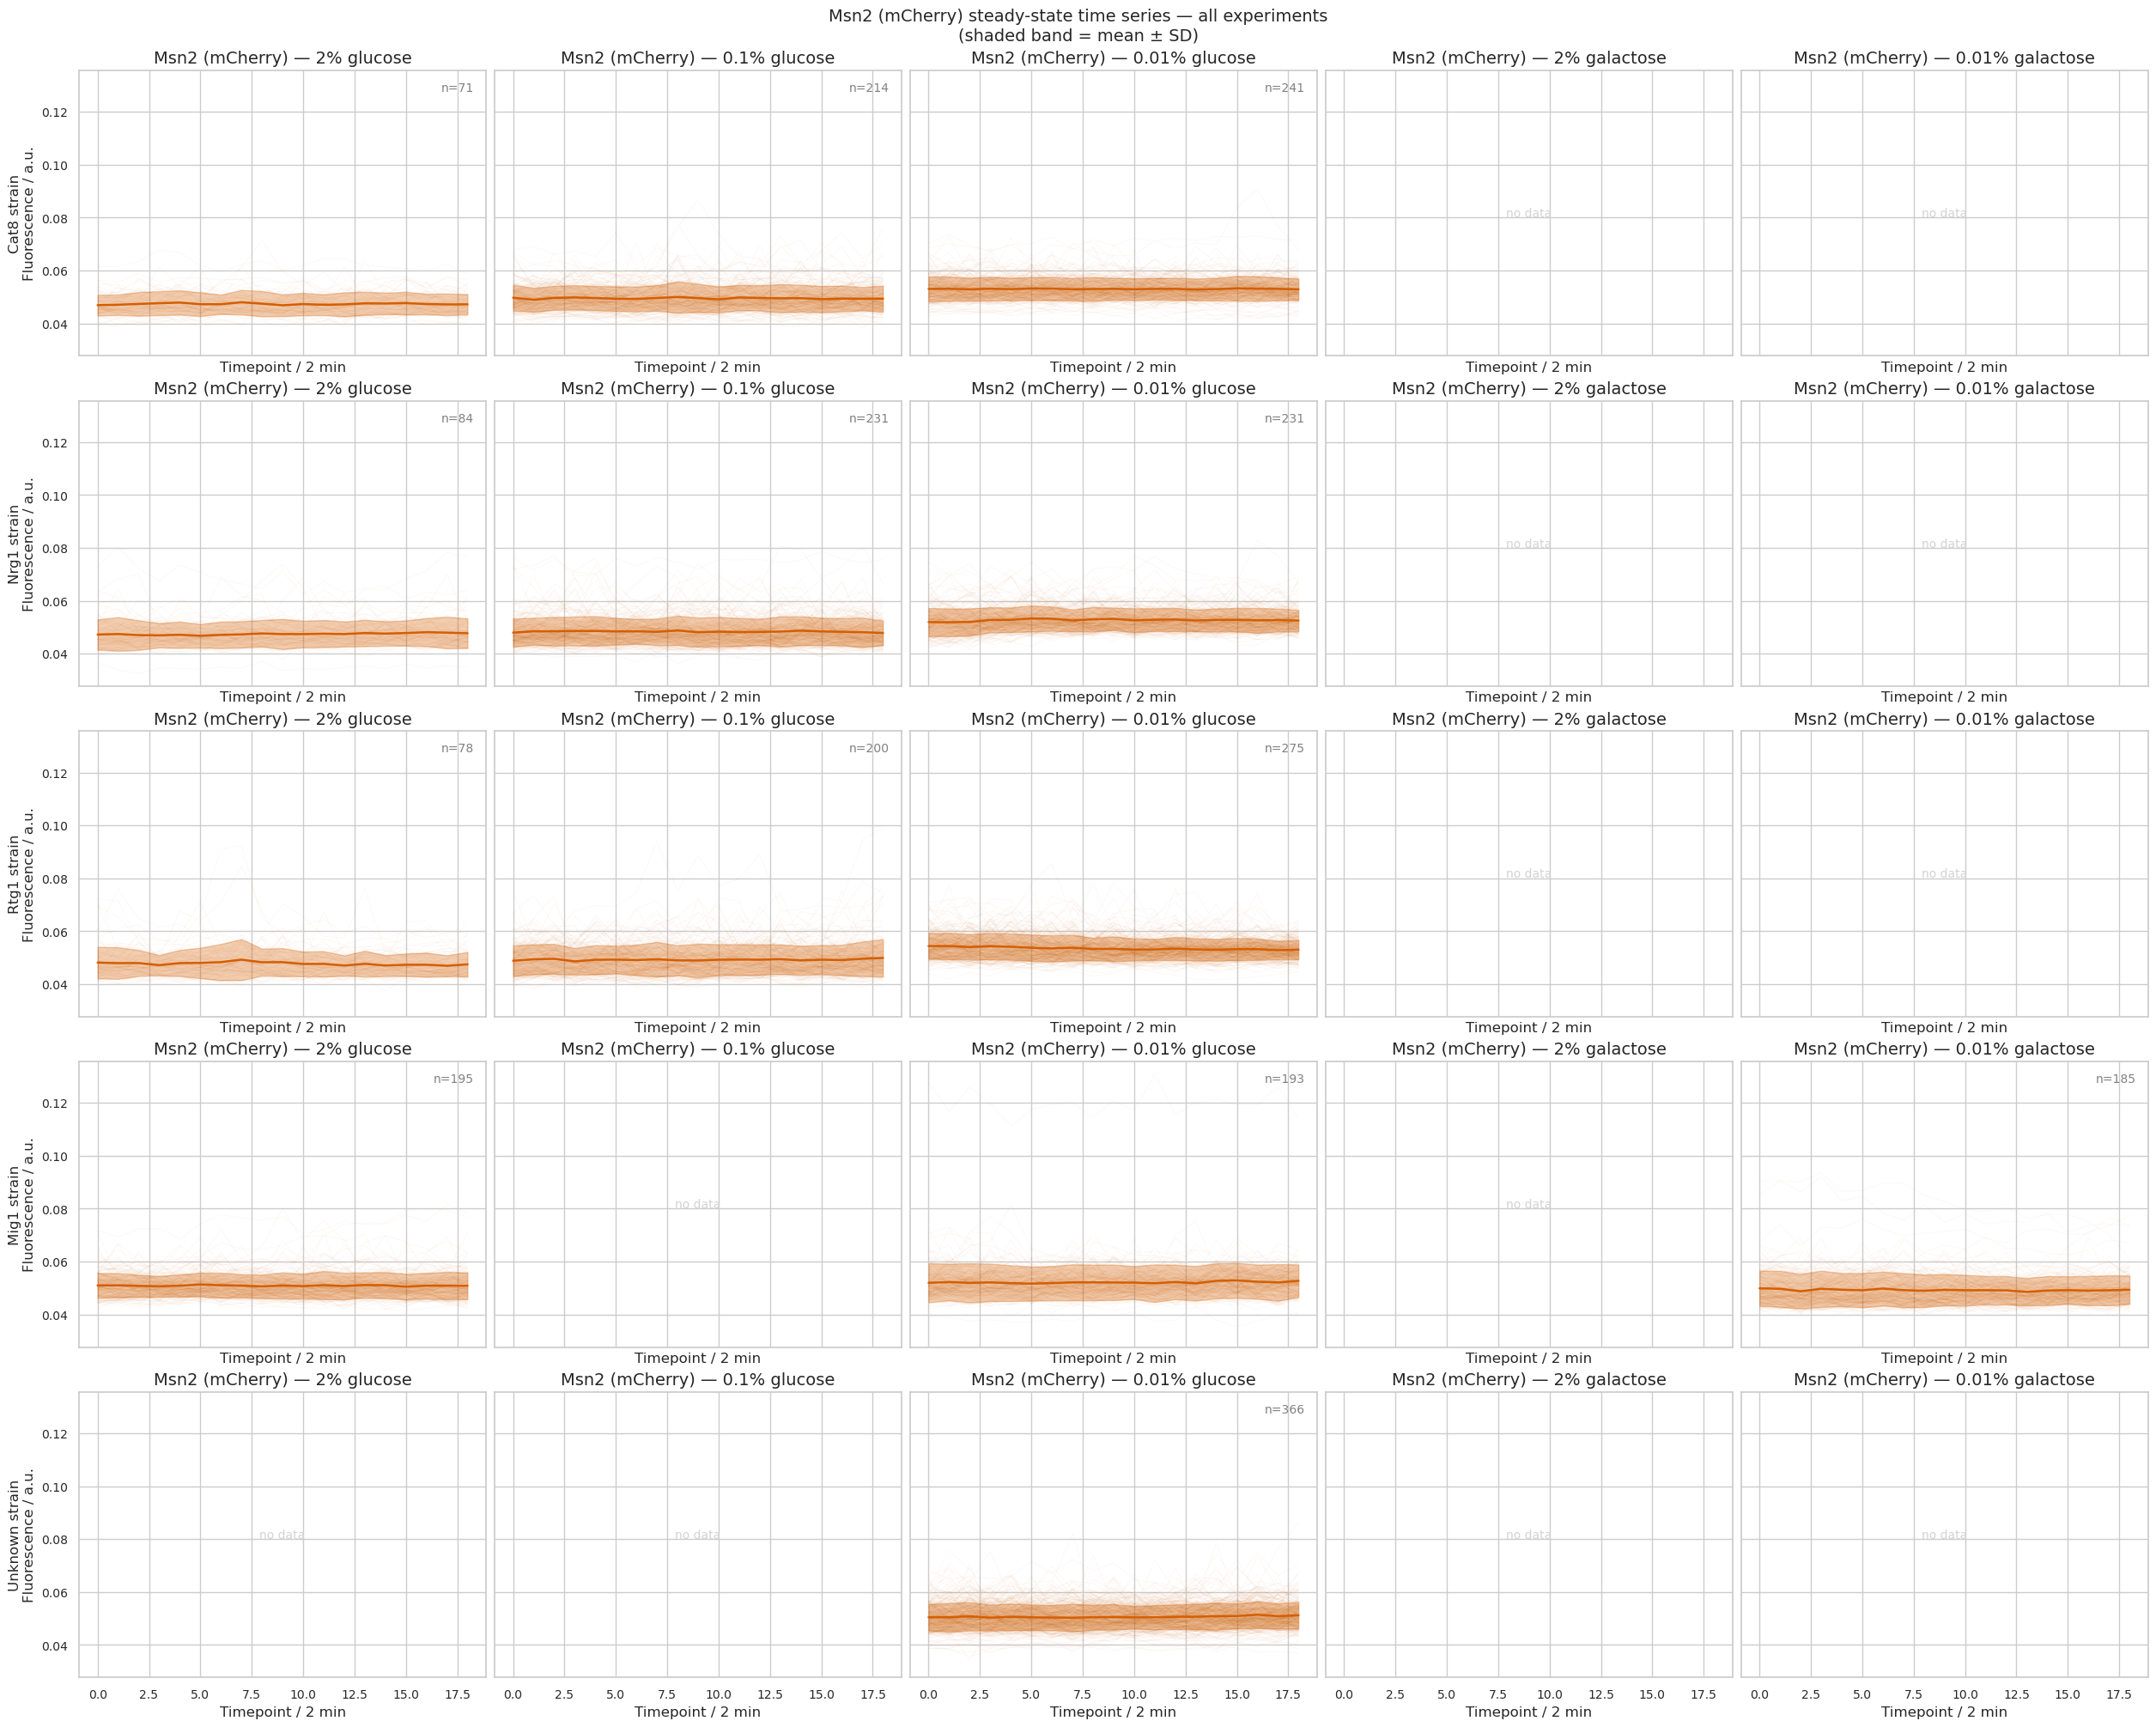

In [4]:
import re as _re

palette  = sns.color_palette("colorblind")
ch_color = palette[3]  # reddish — mCherry

GROUP_TO_TF = {
    "1344": "Cat8", "1344_6": "Cat8",
    "1346": "Nrg1", "1346_4": "Nrg1",
    "1347": "Rtg1",
    "900":  "Mig1",
    "756":  "Unknown", "903": "Unknown",
}

_plot_X, _plot_y, _plot_tf = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        continue
    if "_mCherry_mCherry_" in csv_path.name:
        continue
    label, _ = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)[:, :min_T]

    m = _re.search(r"_group_(.+?)_mCherry_", csv_path.name)
    group_str = m.group(1) if m else "?"
    tf_name = GROUP_TO_TF.get(group_str, f"group_{group_str}")

    _plot_X.append(ts)
    _plot_y.extend([label] * len(ts))
    _plot_tf.extend([tf_name] * len(ts))

_plot_X  = np.vstack(_plot_X)
_plot_y  = np.array(_plot_y)
_plot_tf = np.array(_plot_tf)

tfs_present   = [t for t in ["Cat8", "Nrg1", "Rtg1", "Mig1", "Unknown"] if t in _plot_tf]
conds_present = sorted(set(_plot_y))
t_axis = np.arange(min_T)
n_rows, n_cols = len(tfs_present), len(conds_present)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True, sharex=True,
    constrained_layout=True,
)
axes = np.array(axes).reshape(n_rows, n_cols)

for row, tf in enumerate(tfs_present):
    for col, lbl in enumerate(conds_present):
        ax    = axes[row, col]
        mask  = (_plot_tf == tf) & (_plot_y == lbl)
        X_sub = _plot_X[mask]

        if len(X_sub):
            for trace in X_sub:
                ax.plot(t_axis, trace, color=ch_color, alpha=0.05, linewidth=0.5)
            mean = np.nanmean(X_sub, axis=0)
            sd   = np.nanstd(X_sub, axis=0)
            ax.plot(t_axis, mean, color=ch_color, linewidth=1.8)
            ax.fill_between(t_axis, mean - sd, mean + sd, color=ch_color, alpha=0.3)
            ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=10, color="gray")
        else:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10, color="lightgray")

        ax.set_title(f"Msn2 (mCherry) — {label_names[lbl]}", fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf} strain\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)

fig.suptitle(
    "Msn2 (mCherry) steady-state time series — all experiments\n"
    "(shaded band = mean ± SD)",
    fontsize=14,
)
fig_path = IY021_DIR / "IY021_all_exp_mCherry_trace_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 2. Preprocessing: NaN Fill, Balance & Normalize

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.imputation import fill_nans

X_clean = fill_nans(X_raw)
print(f"NaN remaining: {np.isnan(X_clean).sum()}")

# Balance to minority class
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Balancing to {min_count} samples per class")

rng = np.random.default_rng(42)
bal_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])
X_bal = X_clean[bal_idx]
y_bal = y[bal_idx]

print(f"Balanced: {X_bal.shape}  |  class counts: {np.bincount(y_bal)}")

# Train / test split (80/20, stratified) -- split first, then fit StandardScaler on
# train only, so test-set values never leak into the normalisation statistics.
idx_all = np.arange(len(y_bal))
idx_tr, idx_te = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=y_bal
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_bal[idx_tr])
X_test = scaler.transform(X_bal[idx_te])
y_train, y_test = y_bal[idx_tr], y_bal[idx_te]
print(f"Train {X_train.shape[0]}  |  Test {X_test.shape[0]}")

NaN remaining: 0
Balancing to 578 samples per class
Balanced: (2890, 19)  |  class counts: [578 578 578 578 578]
Train 2312  |  Test 578


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mcherry_simclr_balanced_class_traces.png


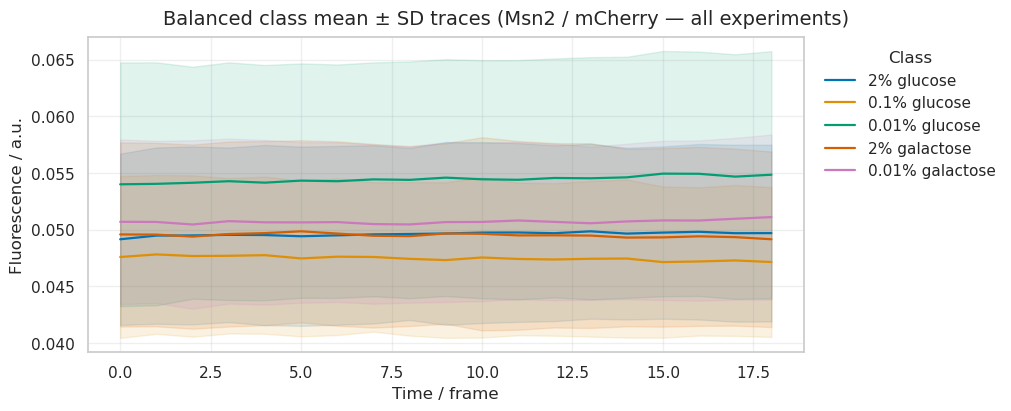

In [6]:
class_names_bal = [label_names[i] for i in sorted(label_names)]
palette = sns.color_palette("colorblind", n_colors=len(class_names_bal))
n_tp = X_bal.shape[1]

fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
for lbl, class_name in enumerate(class_names_bal):
    mask = y_bal == lbl
    mean = X_bal[mask].mean(axis=0)
    sd = X_bal[mask].std(axis=0, ddof=1)
    color = palette[lbl]
    ax.plot(np.arange(n_tp), mean, label=class_name, color=color, linewidth=1.6)
    ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=color, alpha=0.12)

ax.set_xlabel("Time / frame")
ax.set_ylabel("Fluorescence / a.u.")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="Class")
fig.suptitle("Balanced class mean ± SD traces (Msn2 / mCherry — all experiments)", fontsize=14)
fig_path = IY021_DIR / "IY021_all_exp_mcherry_simclr_balanced_class_traces.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()


## 3. SimCLR Model Registry & Helper Functions

In [7]:
from utils.embeddings import make_checkpoint_short_label, make_unique_checkpoint_label
from utils.embeddings import parse_arch_from_name, load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_checkpoint_short_label(p, NORM_OVERRIDES),
            "label": make_unique_checkpoint_label(p, len(MODEL_REGISTRY), NORM_OVERRIDES),
            "experiment": d,
        })

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch_from_name(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")

def run_simclr_svm(model, X_tr, X_te, y_tr, y_te, device):
    """Extract embeddings → StandardScale → SVM (RBF) → (accuracy, y_pred)."""
    Z_tr = encode_channel(model, X_tr, device)
    Z_te = encode_channel(model, X_te, device)
    scaler  = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128 #00                              d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128 #01                              d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16 164413                           d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16 061239                           d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16 151037                            d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #05                                d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #06                                d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16 162432                           d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16 154425                            d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128 #09                               d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16 140729                           d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16 023947                 

## 4. Run All Models

In [8]:
result_rows = []
predictions = {}  # {str(ckpt_path): y_pred}

for row in MODEL_REGISTRY:
    ckpt_path = row["path"]
    label = row["label"]
    print(f"\n{'=' * 70}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")
    try:
        model = load_simclr_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm(model, X_train, X_test, y_train, y_test, DEVICE)
        predictions[str(ckpt_path)] = y_pred
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": acc,
            "status": "ok",
            "error": "",
        })
        print(f"  Accuracy: {acc:.4f}")
    except Exception as exc:
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": np.nan,
            "status": "failed",
            "error": str(exc),
        })
        print(f"  FAILED: {exc}")

results_df = pd.DataFrame(result_rows).sort_values("accuracy", ascending=False, na_position="last").reset_index(drop=True)
results_path = IY021_DIR / "IY021_all_exp_mCherry_simclr_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved: {results_path}")
display(results_df.head(12))


Model: IY017-inst b100 D128 #00
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth


SimCLR encode:   0%|          | 0/10 [00:00<?, ?it/s]

SimCLR encode:  10%|█         | 1/10 [00:00<00:01,  7.39it/s]

SimCLR encode:   0%|          | 0/3 [00:00<?, ?it/s]

  Accuracy: 0.2734

Model: IY017-inst b100 D128 #01
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth


...

  Accuracy: 0.3218

Model: IY024-batch b64 D8 203126
  IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D8_batch-wise_20260419_203126_model.pth


SimCLR encode:   0%|          | 0/10 [00:00<?, ?it/s]

SimCLR encode:   0%|          | 0/3 [00:00<?, ?it/s]

  Accuracy: 0.2941

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_simclr_results.csv


,label,short_label,experiment,checkpoint,checkpoint_name,accuracy,status,error
0,IY024-batch b64 D16 122627,IY024-batch b64 D16,EXP-26-IY024,/home/ianyang/stochastic_simulations/experimen...,IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4...,0.340830,ok,
1,IY017-inst b64 D16 163742,IY017-inst b64 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163...,0.340830,ok,
2,IY017-inst b128 D16 151037,IY017-inst b128 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_15...,0.333910,ok,
3,IY017-inst b2048 D16 162432,IY017-inst b2048 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_1...,0.328720,ok,
4,IY023-batch b1024 D16 183509,IY023-batch b1024 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b1024_lr0.01_L2_H4_D16_batc...,0.323529,ok,
5,IY017-inst b512 D16 154043,IY017-inst b512 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_15...,0.323529,ok,
6,IY017-inst b4096 D16 140729,IY017-inst b4096 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260221_1...,0.321799,ok,
7,IY024-batch b64 D16 210002,IY024-batch b64 D16,EXP-26-IY024,/home/ianyang/stochastic_simulations/experimen...,IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4...,0.321799,ok,
8,IY023-joint b64 D16 165118,IY023-joint b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165...,0.313149,ok,
9,IY023-global b64 D16 130449,IY023-global b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_global...,0.313149,ok,


## 5. Results Visualisation

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_simclr_results.png


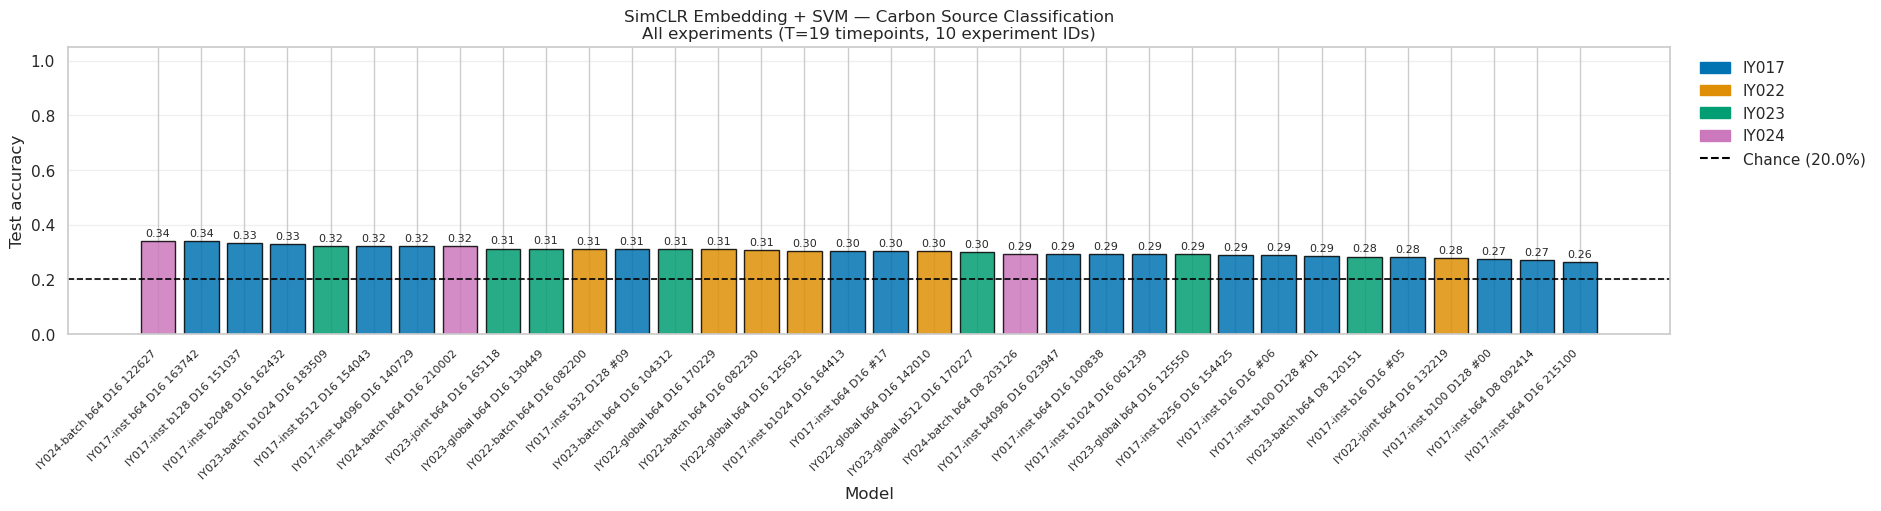

Best model: IY024-batch b64 D16 122627 (0.3408)
Checkpoint: IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth
Chance: 0.2000


In [9]:
valid_results = results_df[results_df["status"] == "ok"].copy()
class_names = [label_names[i] for i in sorted(label_names)]
chance = 1 / len(label_names)
palette = sns.color_palette("colorblind")

color_map = {
    "EXP-26-IY017": palette[0],
    "EXP-26-IY022": palette[1],
    "EXP-26-IY023": palette[2],
    "EXP-26-IY024": palette[4],
}
bar_colors = [color_map.get(exp, palette[7]) for exp in valid_results["experiment"]]

fig, ax = plt.subplots(figsize=(max(14, len(valid_results) * 0.55), 5), constrained_layout=True)
bars = ax.bar(range(len(valid_results)), valid_results["accuracy"], color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
ax.set_xticks(range(len(valid_results)))
ax.set_xticklabels(valid_results["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Test accuracy")
ax.set_title(
    f"SimCLR Embedding + SVM — Carbon Source Classification\n"
    f"All experiments (T={X_train.shape[1]} timepoints, {len(EXPERIMENT_LABELS)} experiment IDs)",
)
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, valid_results["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

legend_handles = [
    Patch(color=palette[0], label="IY017"),
    Patch(color=palette[1], label="IY022"),
    Patch(color=palette[2], label="IY023"),
    Patch(color=palette[4], label="IY024"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"Chance ({chance:.1%})"),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

fig_path = IY021_DIR / "IY021_all_exp_mCherry_simclr_results.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

best = valid_results.iloc[0]
print(f"Best model: {best['label']} ({best['accuracy']:.4f})")
print(f"Checkpoint: {best['checkpoint_name']}")
print(f"Chance: {chance:.4f}")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_all_exp_mCherry_simclr_top_confusion_matrices.png


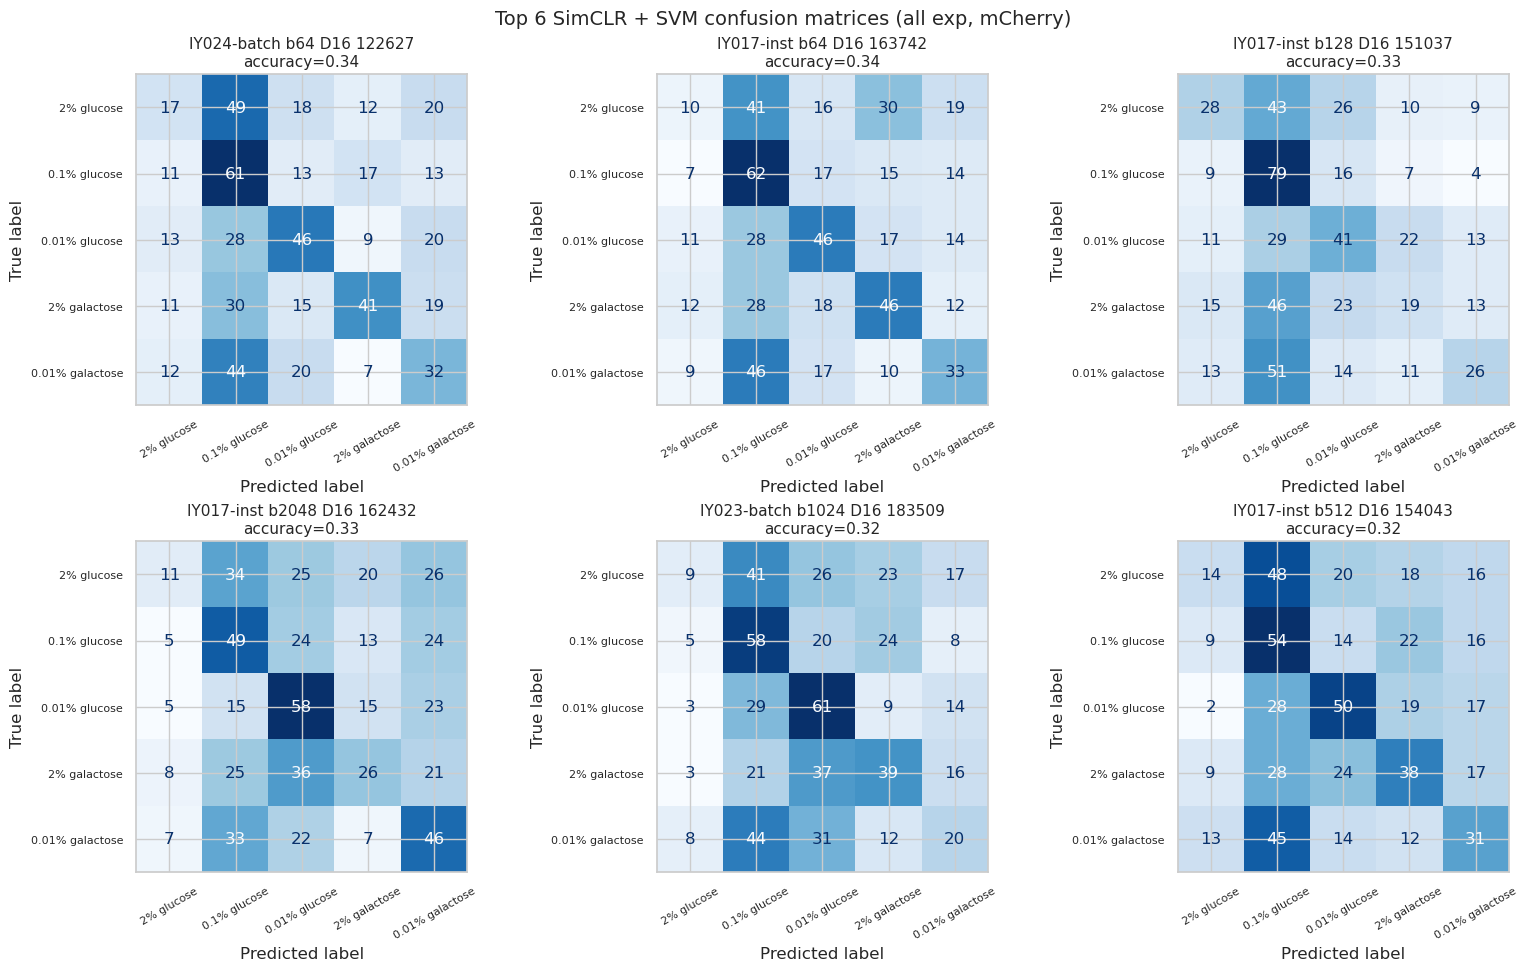

In [10]:
TOP_N_CONFUSION = 6
top_results = valid_results.head(TOP_N_CONFUSION)
ncols = min(3, len(top_results))
nrows = int(np.ceil(len(top_results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, (_, row) in zip(axes, top_results.iterrows()):
    y_pred = predictions[row["checkpoint"]]
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap="Blues",
        xticks_rotation=30,
    )
    ax.set_title(f"{row['label']}\naccuracy={row['accuracy']:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

for ax in axes[len(top_results):]:
    ax.axis("off")

fig.suptitle(f"Top {len(top_results)} SimCLR + SVM confusion matrices (all exp, mCherry)", fontsize=14)
conf_path = IY021_DIR / "IY021_all_exp_mCherry_simclr_top_confusion_matrices.png"
fig.savefig(conf_path, dpi=300, bbox_inches="tight")
print(f"Saved: {conf_path}")
plt.show()

In [11]:
best_checkpoint = valid_results.iloc[0]["checkpoint"]
best_pred = predictions[best_checkpoint]
print(classification_report(y_test, best_pred, target_names=class_names))

                 precision    recall  f1-score   support

     2% glucose       0.27      0.15      0.19       116
   0.1% glucose       0.29      0.53      0.37       115
  0.01% glucose       0.41      0.40      0.40       116
   2% galactose       0.48      0.35      0.41       116
0.01% galactose       0.31      0.28      0.29       115

       accuracy                           0.34       578
      macro avg       0.35      0.34      0.33       578
   weighted avg       0.35      0.34      0.33       578

